# XAS Analysis: Single Processed Run

This notebook analyzes a **processed single-run** H5 file for FLASH2 scan data.

Workflow:
1. Load processed datasets (`vls_cropped`/`vls`, hall GMD, tunnel GMD, fast shutter).
2. Optionally crop VLS again (pixel ROI).
3. Detect open/closed sections from fast shutter first.
4. Build section-wise background from closed trains and compute XAS.
5. Plot XAS vs nominal energy.
6. Inspect hall/tunnel GMD correlations and per-energy diagnostics.

## 0) Imports

Load core Python libraries for H5 IO, array math, and plotting.

In [5]:
import glob
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## 1) Configuration

Set run number, processed-file location, scan grid, shutter sectioning options, optional second VLS crop, and bunch range.

In [24]:
# ---------------- Configuration ----------------
RUN_NO = 58780
INPUT_H5 = "run58780_processed_20260603_154342.h5"  # set explicit path string to force a specific file

PROCESSED_DIR = Path("11022188/processed")

# Nominal scan grid
SCAN_E_START = 270.0
SCAN_E_STOP = 286.0
SCAN_E_STEP = 0.5

# Fast shutter sectioning
TRAIN_RATE_HZ = 10.0
TRANSITION_TRIM_SECONDS = 3.0
REQUIRE_CLOSED_BRACKETS = False

# Optional extra crop on already processed VLS (pixel-axis half-open range)
VLS_PIXEL_CROP = None  # e.g. (20, 80)

# Bunch range used for background-subtracted XAS
BUNCH_RANGE = (10, 39)

print(f"RUN_NO={RUN_NO}, BUNCH_RANGE={BUNCH_RANGE}, VLS_PIXEL_CROP={VLS_PIXEL_CROP}")

RUN_NO=58780, BUNCH_RANGE=(10, 39), VLS_PIXEL_CROP=None


## 2) Load Processed H5

Find the processed file, read datasets, and validate required keys (`vls`/`vls_cropped`, `gmd`, `fast_shutter`).

In [25]:
def _resolve_existing_dir(d):
    p = Path(d).expanduser()
    cands = [p]
    if not p.is_absolute():
        cwd = Path.cwd()
        cands.extend([
            cwd / p,
            cwd.parent / p,
            cwd.parent.parent / p,
        ])
    for c in cands:
        if c.exists() and c.is_dir():
            return c
    return p


def _pick_input_h5(run_no, processed_dir, input_h5=None):
    processed_dir = _resolve_existing_dir(processed_dir)

    if input_h5 is not None:
        p = Path(input_h5).expanduser()

        candidates = [p]
        if not p.is_absolute():
            cwd = Path.cwd()
            candidates = [
                processed_dir / p,
                cwd / p,
                p,
            ]

        for cand in candidates:
            if cand.exists():
                return cand

        tried = " | ".join(str(c) for c in candidates)
        raise FileNotFoundError(f"INPUT_H5 does not exist. Tried: {tried}")

    cands = sorted(processed_dir.glob(f"run{run_no}_processed_*.h5"))
    if not cands:
        raise FileNotFoundError(
            f"No processed file found in {processed_dir} matching run{run_no}_processed_*.h5"
        )
    return cands[-1]


def _read_all_datasets(h5_path):
    out = {}
    with h5py.File(h5_path, "r") as f:
        for k in f.keys():
            obj = f[k]
            if isinstance(obj, h5py.Dataset):
                out[k] = obj[...]
    return out


input_h5 = _pick_input_h5(RUN_NO, PROCESSED_DIR, INPUT_H5)
raw = _read_all_datasets(input_h5)

vls = raw.get("vls_cropped", raw.get("vls", None))
gmd_hall = raw.get("gmd", raw.get("gmd_hall", None))
gmd_tunnel = raw.get("gmd_tunnel", None)
fast_shutter = raw.get("fast_shutter", None)

if vls is None:
    raise KeyError("Missing VLS dataset. Expected key 'vls_cropped' or 'vls'.")
if gmd_hall is None:
    raise KeyError("Missing hall GMD dataset. Expected key 'gmd' or 'gmd_hall'.")
if fast_shutter is None:
    raise KeyError("Missing fast shutter dataset. Expected key 'fast_shutter'.")

vls = np.asarray(vls)
gmd_hall = np.asarray(gmd_hall)
fast_shutter = np.asarray(fast_shutter)
gmd_tunnel = None if gmd_tunnel is None else np.asarray(gmd_tunnel)

if vls.ndim != 3:
    raise ValueError(f"Expected VLS shape (n_train, n_bunch, n_pixel), got {vls.shape}")

print(f"Loaded: {input_h5}")
print("Available keys:", sorted(raw.keys()))
print(f"vls shape: {vls.shape}")
print(f"gmd_hall shape: {gmd_hall.shape}")
print(f"gmd_tunnel shape: {None if gmd_tunnel is None else gmd_tunnel.shape}")
print(f"fast_shutter shape: {fast_shutter.shape}")

Loaded: /Users/hukaiyu/Desktop/PhD/FLASH Beamtime 202605/glycine26/11022188/processed/run58780_processed_20260603_154342.h5
Available keys: ['fast_shutter', 'gmd', 'gmd_tunnel', 'vls_cropped']
vls shape: (52970, 100, 100)
gmd_hall shape: (52970, 100)
gmd_tunnel shape: (52970, 30)
fast_shutter shape: (52970,)


## 3) Utility Functions

Helper functions for contiguous section detection, shutter classification, and robust shot-wise GMD extraction.

In [26]:
def contiguous_true_blocks(mask):
    m = np.asarray(mask, dtype=bool)
    if m.size == 0:
        return []
    x = m.astype(np.int8)
    starts = np.where(np.diff(np.r_[0, x]) == 1)[0]
    ends = np.where(np.diff(np.r_[x, 0]) == -1)[0] + 1
    return list(zip(starts.tolist(), ends.tolist()))


def classify_shutter(sh, train_score):
    arr = np.asarray(sh)
    finite = np.isfinite(arr.astype(float)) if arr.dtype.kind not in ["S", "U", "O"] else np.array([x is not None for x in arr], dtype=bool)

    if arr.dtype.kind in ["S", "U", "O"]:
        s = np.array([str(x).lower() for x in arr], dtype=object)
        is_open = np.array([(("open" in x) or (x in ["1", "on", "true"])) for x in s], dtype=bool)
        is_closed = np.array([(("close" in x) or (x in ["0", "off", "false"])) for x in s], dtype=bool)
    else:
        x = arr.astype(float)
        if finite.sum() < 2:
            raise RuntimeError("Not enough finite shutter samples.")
        lo, hi = np.nanpercentile(x[finite], [10, 90])
        thr = 0.5 * (lo + hi)
        is_open = x >= thr
        is_closed = x < thr

    open_score = np.nanmean(train_score[is_open]) if np.any(is_open) else np.nan
    closed_score = np.nanmean(train_score[is_closed]) if np.any(is_closed) else np.nan
    if np.isfinite(open_score) and np.isfinite(closed_score) and (open_score < closed_score):
        is_open, is_closed = is_closed, is_open

    return is_open, is_closed, finite


def shotify_gmd(gmd, train_indices, bunch_lo, bunch_hi):
    n_train = train_indices.size
    n_bunch = max(0, int(bunch_hi) - int(bunch_lo))
    if n_bunch == 0:
        return np.array([], dtype=np.float64)

    if gmd is None:
        return np.full(n_train * n_bunch, np.nan, dtype=np.float64)

    g = np.asarray(gmd)
    if g.ndim == 1:
        return np.repeat(g[train_indices], n_bunch).astype(np.float64, copy=False)

    if g.ndim != 2:
        return np.full(n_train * n_bunch, np.nan, dtype=np.float64)

    mat = np.full((n_train, n_bunch), np.nan, dtype=np.float64)
    g_lo = int(np.clip(bunch_lo, 0, g.shape[1]))
    g_hi = int(np.clip(bunch_hi, 0, g.shape[1]))
    k = max(0, g_hi - g_lo)
    if k > 0:
        mat[:, :k] = g[train_indices, g_lo:g_hi]
    return mat.reshape(-1)

## 4) Section Division First

Optionally crop VLS again, classify fast-shutter states, trim transitions, and assign section index and nominal energy.

VLS analysis shape: (52970, 100, 100), pixel slice: (0, 100)
Bunch range used: [10, 39)
Detected sections: 33
Open trains kept: 37801
Closed trains kept: 11204


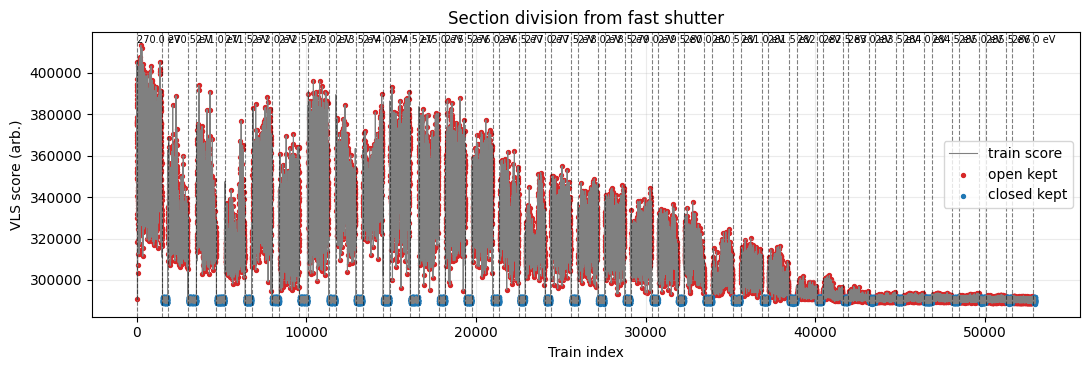

In [27]:
# Optional second VLS crop on pixel axis
if VLS_PIXEL_CROP is None:
    vls_analysis = vls
    pixel_slice = (0, vls.shape[2])
else:
    p0, p1 = VLS_PIXEL_CROP
    vls_analysis = vls[:, :, p0:p1]
    pixel_slice = (int(p0), int(p1))

b0_req, b1_req = BUNCH_RANGE
b0 = int(max(0, b0_req))
b1 = int(min(b1_req, vls_analysis.shape[1]))
if b1 <= b0:
    raise ValueError(f"Invalid BUNCH_RANGE after clipping: ({b0}, {b1})")

train_score = np.nanmean(np.nansum(vls_analysis[:, b0:b1, :], axis=2), axis=1)

is_open_raw, is_closed_raw, finite_sh = classify_shutter(fast_shutter, train_score)

valid_mask = finite_sh.copy()
transition_idx = np.where(np.diff(is_open_raw.astype(np.int8)) != 0)[0] + 1
trim_n = int(round(TRANSITION_TRIM_SECONDS * TRAIN_RATE_HZ))
for t in transition_idx:
    i0 = max(0, t - trim_n)
    i1 = min(valid_mask.size, t + trim_n + 1)
    valid_mask[i0:i1] = False

open_blocks = contiguous_true_blocks(is_open_raw & finite_sh)
if REQUIRE_CLOSED_BRACKETS:
    bracketed = []
    for s, e in open_blocks:
        left_closed = (s > 0) and finite_sh[s - 1] and (not is_open_raw[s - 1])
        right_closed = (e < is_open_raw.size) and finite_sh[e] and (not is_open_raw[e])
        if left_closed and right_closed:
            bracketed.append((s, e))
    if bracketed:
        open_blocks = bracketed

if not open_blocks:
    raise RuntimeError("No open sections detected from fast shutter.")

scan_energies = np.arange(SCAN_E_START, SCAN_E_STOP + 0.5 * SCAN_E_STEP, SCAN_E_STEP, dtype=float)
n_scan = scan_energies.size
n_detected = len(open_blocks)
if n_detected > n_scan:
    open_blocks = open_blocks[:n_scan]
    n_detected = n_scan

section_idx = np.full(is_open_raw.shape, -1, dtype=np.int32)
for i, (s, e) in enumerate(open_blocks):
    section_idx[s:e] = i

is_open = (section_idx >= 0) & valid_mask & is_open_raw
is_closed = is_closed_raw & valid_mask
section_nominal = scan_energies[:n_detected]

print(f"VLS analysis shape: {vls_analysis.shape}, pixel slice: {pixel_slice}")
print(f"Bunch range used: [{b0}, {b1})")
print(f"Detected sections: {len(open_blocks)}")
print(f"Open trains kept: {int(np.sum(is_open))}")
print(f"Closed trains kept: {int(np.sum(is_closed))}")

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(train_score, lw=0.8, color="0.5", label="train score")
ax.scatter(np.where(is_open)[0], train_score[is_open], s=8, color="tab:red", label="open kept")
ax.scatter(np.where(is_closed)[0], train_score[is_closed], s=8, color="tab:blue", label="closed kept")
for i, (s, e) in enumerate(open_blocks):
    ax.axvline(s, ls="--", lw=0.8, color="k", alpha=0.5)
    ax.axvline(e, ls="--", lw=0.8, color="k", alpha=0.5)
    ax.text(s, np.nanmax(train_score), f"{section_nominal[i]:.1f} eV", fontsize=7, va="bottom")
ax.set_title("Section division from fast shutter")
ax.set_xlabel("Train index")
ax.set_ylabel("VLS score (arb.)")
ax.grid(alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()
plt.show()

## 5) Build Background And Compute Shot-Level XAS Inputs

Use closed-train backgrounds per section, subtract from open-train VLS, then build shot-wise arrays for VLS, hall GMD, tunnel GMD, and nominal energy.

In [28]:
if not np.any(is_open):
    raise RuntimeError("No open trains kept after sectioning.")
if not np.any(is_closed):
    raise RuntimeError("No closed trains kept after sectioning.")

shot_vls_parts = []
shot_gmd_hall_parts = []
shot_gmd_tunnel_parts = []
shot_nom_parts = []

closed_blocks = contiguous_true_blocks(is_closed)

def _prev_closed_indices(open_start):
    prev = None
    for cs, ce in closed_blocks:
        if ce <= open_start:
            prev = (cs, ce)
        else:
            break
    if prev is None:
        return np.array([], dtype=np.int64)
    ps, pe = prev
    return np.arange(ps, pe, dtype=np.int64)

first_closed_idx = np.arange(closed_blocks[0][0], closed_blocks[0][1], dtype=np.int64)

for i, (s, e) in enumerate(open_blocks):
    sec_open_mask = is_open & (section_idx == i)
    sec_open_idx = np.where(sec_open_mask)[0]
    if sec_open_idx.size == 0:
        continue

    if i == 0:
        sec_closed_idx = first_closed_idx
    else:
        sec_closed_idx = _prev_closed_indices(s)
    if sec_closed_idx.size == 0:
        sec_closed_idx = np.where(is_closed)[0]

    bg2d = np.nanmean(vls_analysis[sec_closed_idx, :, :], axis=0)
    sec_vls = vls_analysis[sec_open_idx, b0:b1, :] - bg2d[np.newaxis, b0:b1, :]
    sec_vls_sum = np.nansum(sec_vls, axis=2).reshape(-1)

    sec_gmd_hall = shotify_gmd(gmd_hall, sec_open_idx, b0, b1)
    sec_gmd_tunnel = shotify_gmd(gmd_tunnel, sec_open_idx, b0, b1)
    sec_nom = np.full(sec_vls_sum.shape, section_nominal[i], dtype=np.float64)

    shot_vls_parts.append(sec_vls_sum)
    shot_gmd_hall_parts.append(sec_gmd_hall)
    shot_gmd_tunnel_parts.append(sec_gmd_tunnel)
    shot_nom_parts.append(sec_nom)

shot_vls = np.concatenate(shot_vls_parts)
shot_gmd_hall = np.concatenate(shot_gmd_hall_parts)
shot_gmd_tunnel = np.concatenate(shot_gmd_tunnel_parts)
shot_nom = np.concatenate(shot_nom_parts)

good_xas = np.isfinite(shot_vls) & np.isfinite(shot_gmd_hall) & np.isfinite(shot_nom)
shot_vls = shot_vls[good_xas]
shot_gmd_hall = shot_gmd_hall[good_xas]
shot_gmd_tunnel = shot_gmd_tunnel[good_xas]
shot_nom = shot_nom[good_xas]

xas_total = np.nansum(shot_gmd_hall) / np.nansum(shot_vls)
print(f"Valid shots for XAS: {shot_vls.size}")
print(f"Overall XAS = sum(GMD_hall) / sum(VLS_bgsub): {xas_total:.6g}")

Valid shots for XAS: 756020
Overall XAS = sum(GMD_hall) / sum(VLS_bgsub): 0.000100691


## 6) XAS Plot

Compute binned XAS per nominal energy and reproduce the scan plot.

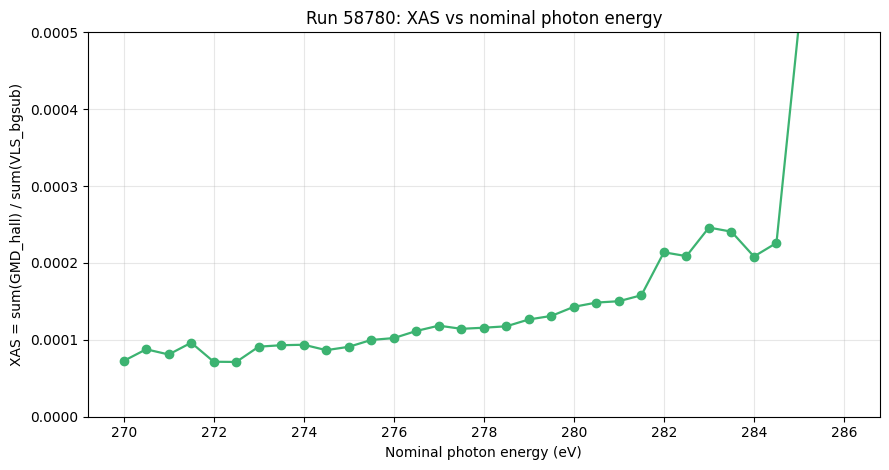

  E_nom (eV)   n shots           XAS
--------------------------------------
    270.0000     29600   7.25632e-05
    270.5000     22820   8.77156e-05
    271.0000     22320   8.09471e-05
    271.5000     22440   9.62853e-05
    272.0000     22620    7.1511e-05
    272.5000     22620   7.12489e-05
    273.0000     23200   9.11174e-05
    273.5000     22200   9.30096e-05
    274.0000     22760   9.36372e-05
    274.5000     22900   8.65802e-05
    275.0000     22740   9.09371e-05
    275.5000     22540   9.98746e-05
    276.0000     23060   0.000102274
    276.5000     21880   0.000111547
    277.0000     22520   0.000118449
    277.5000     22920    0.00011435
    278.0000     22380   0.000115771
    278.5000     22420   0.000117624
    279.0000     23100    0.00012652
    279.5000     22080   0.000131107
    280.0000     22680   0.000142958
    280.5000     22880   0.000148475
    281.0000     23660   0.000150247
    281.5000     22840   0.000158032
    282.0000     22080   0.000213883

In [35]:
e_grid = np.arange(SCAN_E_START, SCAN_E_STOP + 0.5 * SCAN_E_STEP, SCAN_E_STEP, dtype=float)
e_vals, x_vals, n_vals = [], [], []

for e0 in e_grid:
    m = np.isclose(shot_nom, e0, atol=1e-8)
    if not np.any(m):
        continue
    den = np.nansum(shot_vls[m])
    if np.abs(den) < 1e-12:
        continue
    e_vals.append(float(e0))
    x_vals.append(float(np.nansum(shot_gmd_hall[m]) / den))
    n_vals.append(int(np.sum(m)))

e_vals = np.asarray(e_vals, dtype=float)
x_vals = np.asarray(x_vals, dtype=float)
n_vals = np.asarray(n_vals, dtype=int)

order = np.argsort(e_vals)
e_vals = e_vals[order]
x_vals = x_vals[order]
n_vals = n_vals[order]

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(e_vals, x_vals, "o-", color="mediumseagreen", lw=1.6)
ax.set_xlabel("Nominal photon energy (eV)")
ax.set_ylabel("XAS = sum(GMD_hall) / sum(VLS_bgsub)")
ax.set_title(f"Run {RUN_NO}: XAS vs nominal photon energy")
ax.grid(alpha=0.3)
ax.set_ylim(0, 0.0005)
fig.tight_layout()
plt.show()

print(f"{'E_nom (eV)':>12s}  {'n shots':>8s}  {'XAS':>12s}")
print("-" * 38)
for e, n, x in zip(e_vals, n_vals, x_vals):
    print(f"{e:12.4f}  {n:8d}  {x:12.6g}")

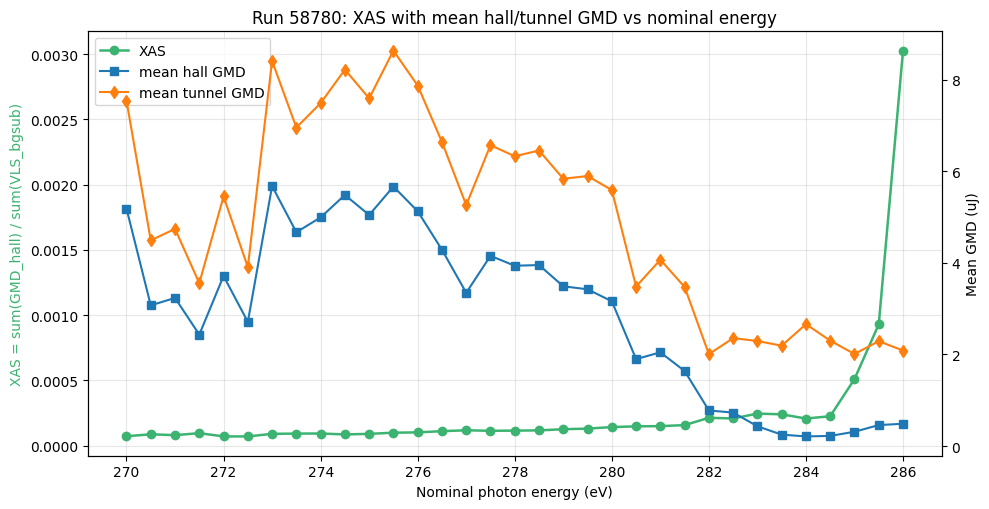

 E_nom(eV)        n           XAS     mean_hall   mean_tunnel   tunnel/hall
-----------------------------------------------------------------------------------
   270.000    29600   7.25632e-05       5.18814       7.54531       1.45434
   270.500    22820   8.77156e-05       3.07313       4.49246       1.46185
   271.000    22320   8.09471e-05       3.23489        4.7442       1.46657
   271.500    22440   9.62853e-05       2.43362       3.55872       1.46232
   272.000    22620    7.1511e-05       3.71459       5.45215       1.46777
   272.500    22620   7.12489e-05       2.71155       3.90804       1.44125
   273.000    23200   9.11174e-05       5.67875       8.41251        1.4814
   273.500    22200   9.30096e-05       4.67068       6.95839        1.4898
   274.000    22760   9.36372e-05       4.99494       7.49122       1.49976
   274.500    22900   8.65802e-05       5.48522       8.22341       1.49919
   275.000    22740   9.09371e-05        5.0472       7.59551        1.5049
   2

In [30]:
# XAS with mean hall/tunnel GMD per nominal photon energy
nominal_grid = np.sort(np.unique(shot_nom[np.isfinite(shot_nom)]))

xas_per_e = []
mean_hall_per_e = []
mean_tunnel_per_e = []
gmd_ratio_tunnel_over_hall = []
n_per_e = []

for e0 in nominal_grid:
    m = np.isclose(shot_nom, e0, atol=1e-8)
    if not np.any(m):
        continue

    v = shot_vls[m]
    gh = shot_gmd_hall[m]
    gt = shot_gmd_tunnel[m]

    good_xas = np.isfinite(v) & np.isfinite(gh)
    den = np.nansum(v[good_xas])
    xas_e = np.nansum(gh[good_xas]) / den if np.any(good_xas) and np.abs(den) > 1e-12 else np.nan

    mean_h = float(np.nanmean(gh))
    mean_t = float(np.nanmean(gt)) if np.any(np.isfinite(gt)) else np.nan
    ratio_th = (mean_t / mean_h) if np.isfinite(mean_t) and np.isfinite(mean_h) and np.abs(mean_h) > 1e-12 else np.nan

    xas_per_e.append(float(xas_e))
    mean_hall_per_e.append(mean_h)
    mean_tunnel_per_e.append(mean_t)
    gmd_ratio_tunnel_over_hall.append(ratio_th)
    n_per_e.append(int(np.sum(m)))

nominal_grid = np.asarray(nominal_grid, dtype=float)
xas_per_e = np.asarray(xas_per_e, dtype=float)
mean_hall_per_e = np.asarray(mean_hall_per_e, dtype=float)
mean_tunnel_per_e = np.asarray(mean_tunnel_per_e, dtype=float)
gmd_ratio_tunnel_over_hall = np.asarray(gmd_ratio_tunnel_over_hall, dtype=float)
n_per_e = np.asarray(n_per_e, dtype=int)

fig, ax1 = plt.subplots(figsize=(10, 5.2))
ax2 = ax1.twinx()

l1 = ax1.plot(nominal_grid, xas_per_e, "o-", lw=1.8, color="mediumseagreen", label="XAS")
l2 = ax2.plot(nominal_grid, mean_hall_per_e, "s-", lw=1.5, color="tab:blue", label="mean hall GMD")
l3 = ax2.plot(nominal_grid, mean_tunnel_per_e, "d-", lw=1.5, color="tab:orange", label="mean tunnel GMD")

ax1.set_xlabel("Nominal photon energy (eV)")
ax1.set_ylabel("XAS = sum(GMD_hall) / sum(VLS_bgsub)", color="mediumseagreen")
ax2.set_ylabel("Mean GMD (uJ)")
ax1.set_title(f"Run {RUN_NO}: XAS with mean hall/tunnel GMD vs nominal energy")
ax1.grid(alpha=0.3)

lines = l1 + l2 + l3
labels = [ln.get_label() for ln in lines]
ax1.legend(lines, labels, loc="upper left")

fig.tight_layout()
plt.show()

print(f"{'E_nom(eV)':>10s}  {'n':>7s}  {'XAS':>12s}  {'mean_hall':>12s}  {'mean_tunnel':>12s}  {'tunnel/hall':>12s}")
print("-" * 83)
for e0, n, x, mh, mt, rth in zip(
    nominal_grid,
    n_per_e,
    xas_per_e,
    mean_hall_per_e,
    mean_tunnel_per_e,
    gmd_ratio_tunnel_over_hall,
):
    print(f"{e0:10.3f}  {n:7d}  {x:12.6g}  {mh:12.6g}  {mt:12.6g}  {rth:12.6g}")

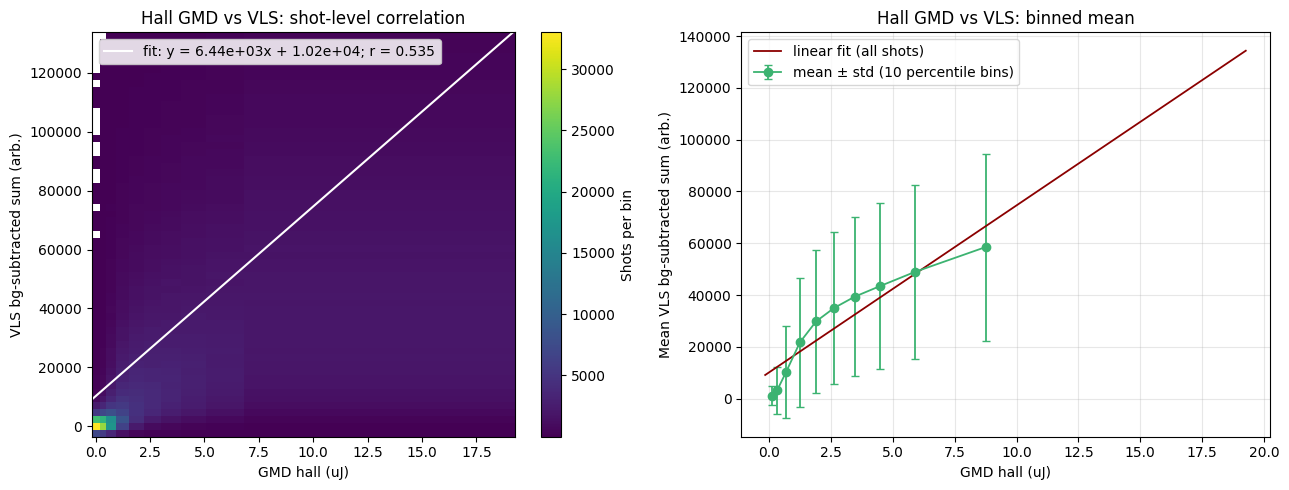

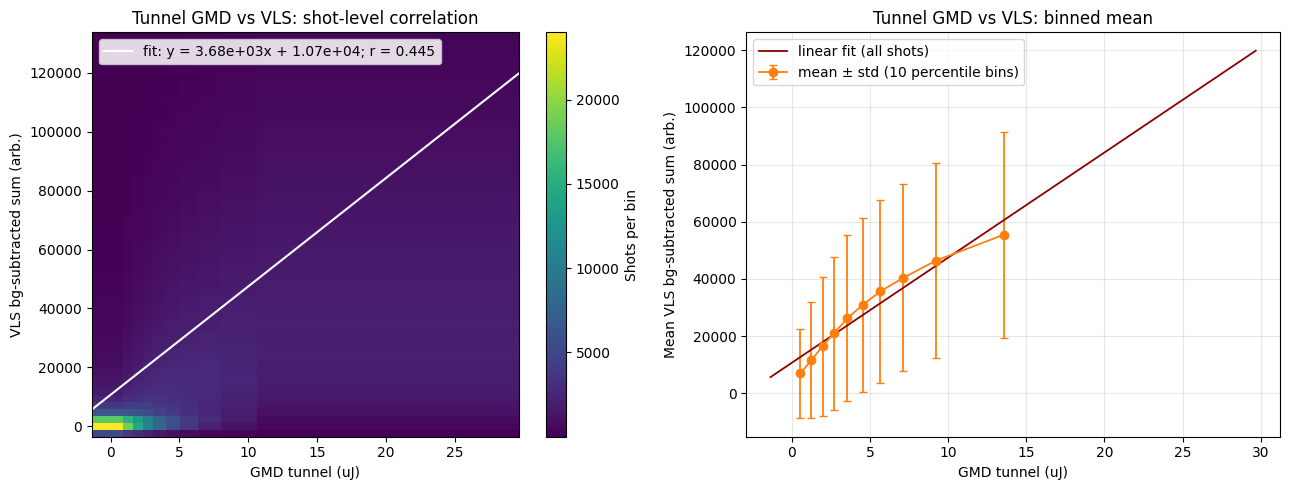

Hall-Tunnel Pearson r = 0.9642  (n=756020)


In [31]:
# Correlation checks (style similar to vls_inspect): hist2d + linear fit + binned mean

def _corr_panels(x, y, x_label, y_label, title_prefix, point_color):
    m = np.isfinite(x) & np.isfinite(y)
    xg = np.asarray(x[m], dtype=float)
    yg = np.asarray(y[m], dtype=float)
    if xg.size < 20:
        print(f"{title_prefix}: not enough valid points for correlation plot")
        return

    n_bins = 10
    x_edges = np.percentile(xg, np.linspace(0, 100, n_bins + 1))
    x_edges = np.unique(x_edges)
    if x_edges.size < 3:
        print(f"{title_prefix}: x has too few unique values for percentile binning")
        return

    # Recompute n_bins if percentile edges collapse.
    n_bins = x_edges.size - 1

    bin_idx = np.digitize(xg, x_edges[1:-1], right=False)
    x_mean = np.full(n_bins, np.nan, dtype=float)
    y_mean = np.full(n_bins, np.nan, dtype=float)
    y_std = np.full(n_bins, np.nan, dtype=float)
    n_per = np.zeros(n_bins, dtype=int)

    for i in range(n_bins):
        bm = bin_idx == i
        n_per[i] = int(np.sum(bm))
        if n_per[i] == 0:
            continue
        xb = xg[bm]
        yb = yg[bm]
        x_mean[i] = np.nanmean(xb)
        y_mean[i] = np.nanmean(yb)
        if n_per[i] > 1:
            y_std[i] = np.nanstd(yb, ddof=1)

    r = float(np.corrcoef(xg, yg)[0, 1])
    slope, intercept = np.polyfit(xg, yg, 1)
    x_line = np.linspace(np.nanmin(xg), np.nanmax(xg), 200)

    y_lo, y_hi = np.nanpercentile(yg, [1, 99])
    if not np.isfinite(y_lo) or not np.isfinite(y_hi) or y_hi <= y_lo:
        y_lo, y_hi = np.nanmin(yg), np.nanmax(yg)
    y_edges = np.linspace(y_lo, y_hi, 60)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    h = ax1.hist2d(xg, yg, bins=[x_edges, y_edges], cmap="viridis", cmin=1)
    fig.colorbar(h[3], ax=ax1, label="Shots per bin")
    ax1.plot(x_line, slope * x_line + intercept, color="white", lw=1.5,
             label=f"fit: y = {slope:.3g}x + {intercept:.3g}; r = {r:.3f}")
    ax1.set_xlabel(x_label)
    ax1.set_ylabel(y_label)
    ax1.set_title(f"{title_prefix}: shot-level correlation")
    ax1.legend(loc="upper left", framealpha=0.85)

    good_bins = np.isfinite(x_mean) & np.isfinite(y_mean)
    ax2.errorbar(x_mean[good_bins], y_mean[good_bins], yerr=y_std[good_bins],
                 fmt="o-", lw=1.3, capsize=3, color=point_color,
                 label=f"mean ± std ({n_bins} percentile bins)")
    ax2.plot(x_line, slope * x_line + intercept, color="darkred", lw=1.3,
             label="linear fit (all shots)")
    ax2.set_xlabel(x_label)
    ax2.set_ylabel(f"Mean {y_label}")
    ax2.set_title(f"{title_prefix}: binned mean")
    ax2.grid(alpha=0.3)
    ax2.legend(loc="upper left")

    fig.tight_layout()
    plt.show()


_corr_panels(
    shot_gmd_hall,
    shot_vls,
    x_label="GMD hall (uJ)",
    y_label="VLS bg-subtracted sum (arb.)",
    title_prefix="Hall GMD vs VLS",
    point_color="mediumseagreen",
)

_corr_panels(
    shot_gmd_tunnel,
    shot_vls,
    x_label="GMD tunnel (uJ)",
    y_label="VLS bg-subtracted sum (arb.)",
    title_prefix="Tunnel GMD vs VLS",
    point_color="tab:orange",
)

m_ht = np.isfinite(shot_gmd_hall) & np.isfinite(shot_gmd_tunnel)
if np.sum(m_ht) > 20:
    r_ht = float(np.corrcoef(shot_gmd_hall[m_ht], shot_gmd_tunnel[m_ht])[0, 1])
    print(f"Hall-Tunnel Pearson r = {r_ht:.4f}  (n={int(np.sum(m_ht))})")
else:
    print("Not enough valid hall+tunnel points for direct hall-tunnel correlation.")

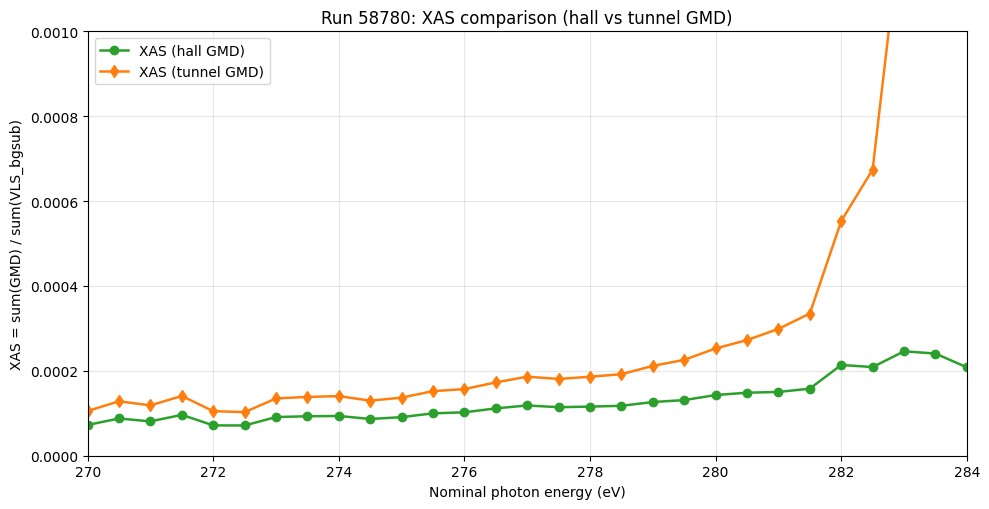

 E_nom(eV)      XAS_hall    XAS_tunnel   tunnel/hall    n_hall   n_tunnel
-------------------------------------------------------------------------------
   270.000   7.25632e-05   0.000105531       1.45434     29600      29600
   270.500   8.77156e-05   0.000128227       1.46185     22820      22820
   271.000   8.09471e-05   0.000118715       1.46657     22320      22320
   271.500   9.62853e-05     0.0001408       1.46232     22440      22440
   272.000    7.1511e-05   0.000104961       1.46777     22620      22620
   272.500   7.12489e-05   0.000102688       1.44125     22620      22620
   273.000   9.11174e-05   0.000134981        1.4814     23200      23200
   273.500   9.30096e-05   0.000138566        1.4898     22200      22200
   274.000   9.36372e-05   0.000140434       1.49976     22760      22760
   274.500   8.65802e-05     0.0001298       1.49919     22900      22900
   275.000   9.09371e-05   0.000136851        1.5049     22740      22740
   275.500   9.98746e-05     0.0

In [40]:
# Compare XAS using hall GMD vs tunnel GMD on the same figure
nominal_grid_cmp = np.sort(np.unique(shot_nom[np.isfinite(shot_nom)]))

xas_hall = []
xas_tunnel = []
n_hall = []
n_tunnel = []

for e0 in nominal_grid_cmp:
    m = np.isclose(shot_nom, e0, atol=1e-8)
    if not np.any(m):
        continue

    v = shot_vls[m]
    gh = shot_gmd_hall[m]
    gt = shot_gmd_tunnel[m]

    good_h = np.isfinite(v) & np.isfinite(gh)
    den_h = np.nansum(v[good_h])
    xh = np.nansum(gh[good_h]) / den_h if np.any(good_h) and np.abs(den_h) > 1e-12 else np.nan

    good_t = np.isfinite(v) & np.isfinite(gt)
    den_t = np.nansum(v[good_t])
    xt = np.nansum(gt[good_t]) / den_t if np.any(good_t) and np.abs(den_t) > 1e-12 else np.nan

    xas_hall.append(float(xh))
    xas_tunnel.append(float(xt))
    n_hall.append(int(np.sum(good_h)))
    n_tunnel.append(int(np.sum(good_t)))

nominal_grid_cmp = np.asarray(nominal_grid_cmp, dtype=float)
xas_hall = np.asarray(xas_hall, dtype=float)
xas_tunnel = np.asarray(xas_tunnel, dtype=float)
n_hall = np.asarray(n_hall, dtype=int)
n_tunnel = np.asarray(n_tunnel, dtype=int)

fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(nominal_grid_cmp, xas_hall, "o-", lw=1.8, color="tab:green", label="XAS (hall GMD)")
ax.plot(nominal_grid_cmp, xas_tunnel, "d-", lw=1.8, color="tab:orange", label="XAS (tunnel GMD)")
ax.set_xlabel("Nominal photon energy (eV)")
ax.set_ylabel("XAS = sum(GMD) / sum(VLS_bgsub)")
ax.set_title(f"Run {RUN_NO}: XAS comparison (hall vs tunnel GMD)")
ax.set_ylim(0, 0.001)
ax.set_xlim(270,284)
ax.grid(alpha=0.3)
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

print(f"{'E_nom(eV)':>10s}  {'XAS_hall':>12s}  {'XAS_tunnel':>12s}  {'tunnel/hall':>12s}  {'n_hall':>8s}  {'n_tunnel':>9s}")
print("-" * 79)
for e0, xh, xt, nh, nt in zip(nominal_grid_cmp, xas_hall, xas_tunnel, n_hall, n_tunnel):
    ratio = (xt / xh) if np.isfinite(xt) and np.isfinite(xh) and np.abs(xh) > 1e-12 else np.nan
    print(f"{e0:10.3f}  {xh:12.6g}  {xt:12.6g}  {ratio:12.6g}  {nh:8d}  {nt:9d}")